<a href="https://colab.research.google.com/github/D-Rockie/Deep-Learning-Lab-2026/blob/main/DLexp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3002s 18us/step


In [3]:
import os

In [4]:
os.makedirs('plots', exist_ok=True)

def save_plot(fig, name):
    fig.savefig(f'plots/{name}.eps', format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved plots/{name}.eps")

In [5]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck']

print("Train images shape:", x_train.shape)
print("Train labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Number of classes:", len(class_names))

Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10


Saved plots/sample_images.eps


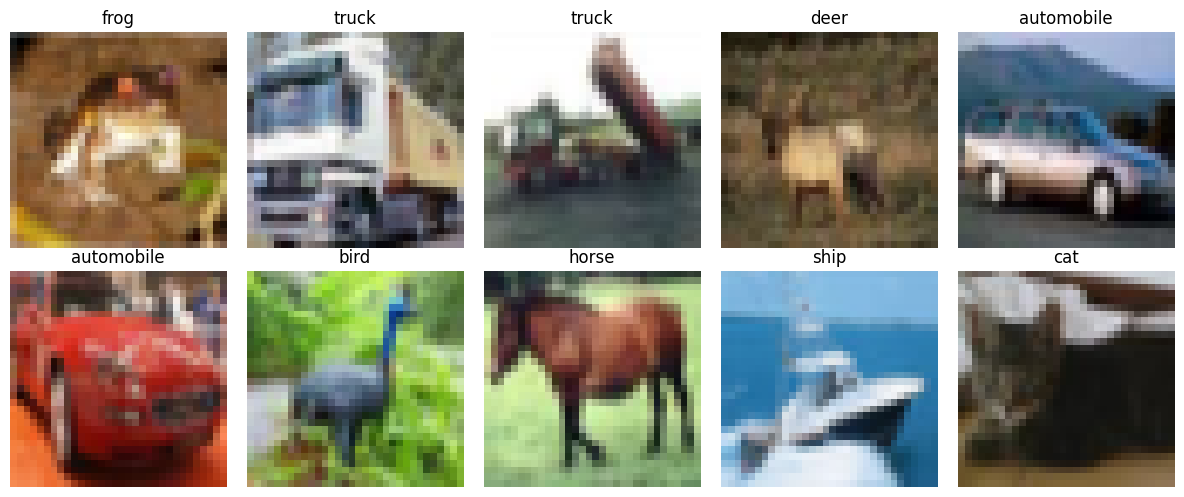

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.tight_layout()
save_plot(fig, "sample_images")
plt.show()

Saved plots/class_distribution.eps


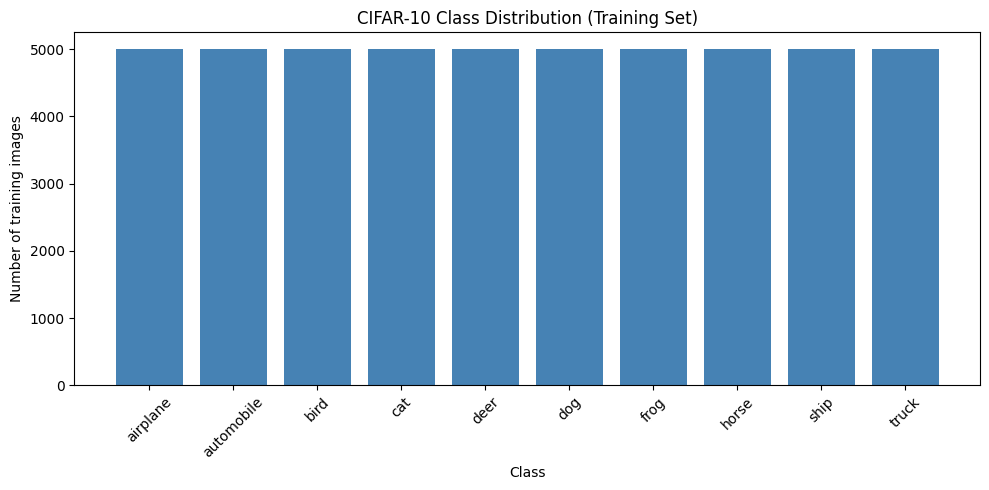

Count per class: {'airplane': np.int64(5000), 'automobile': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [7]:
unique, counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([class_names[i] for i in unique], counts, color='steelblue')
ax.set_xlabel("Class")
ax.set_ylabel("Number of training images")
ax.set_title("CIFAR-10 Class Distribution (Training Set)")
plt.xticks(rotation=45)
plt.tight_layout()
save_plot(fig, "class_distribution")
plt.show()

print("Count per class:", dict(zip([class_names[i] for i in unique], counts)))

Task 2

In [15]:
# Cell 5: Single convolution layer with varying kernel sizes
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.models import Sequential

input_shape = (32, 32, 3)
kernel_sizes = [3, 5, 7]

feature_map_sizes = {}

for k in kernel_sizes:
    model = Sequential([
        Conv2D(filters=16, kernel_size=(k, k), strides=1, padding='valid',
               input_shape=input_shape)
    ])
    output_shape = model.output_shape  # (None, H, W, C)
    feature_map_sizes[k] = output_shape
    print(f"Kernel {k}x{k} -> Output feature map shape: {output_shape}")

Kernel 3x3 -> Output feature map shape: (None, 30, 30, 16)
Kernel 5x5 -> Output feature map shape: (None, 28, 28, 16)
Kernel 7x7 -> Output feature map shape: (None, 26, 26, 16)


In [16]:
# Cell 6: Verify against the formula manually
N = 32       # input size
P = 0        # no padding (padding='valid')
S = 1        # stride

print(f"{'Kernel':<10}{'Formula Output':<20}{'Keras Output'}")
for k in kernel_sizes:
    formula_output = (N - k + 2*P) // S + 1
    keras_output = feature_map_sizes[k][1]  # height dimension
    print(f"{k}x{k:<8}{formula_output:<20}{keras_output}")

Kernel    Formula Output      Keras Output
3x3       30                  30
5x5       28                  28
7x7       26                  26


Saved plots/kernel_size_vs_feature_map.eps


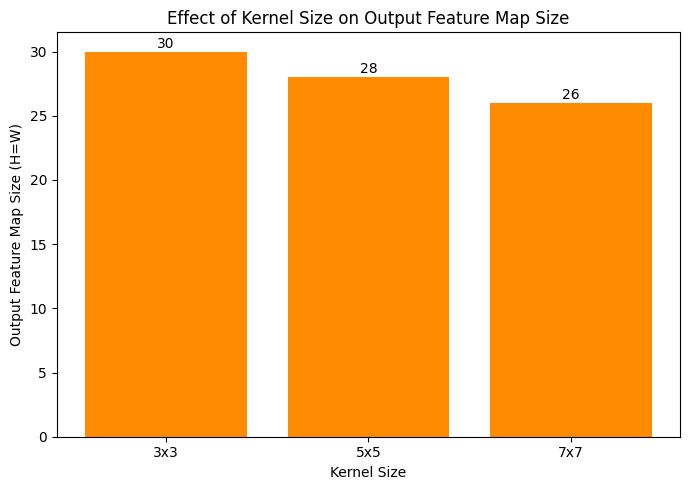

In [17]:
# Cell 7: Bar chart comparing feature map sizes across kernel sizes
fig, ax = plt.subplots(figsize=(7, 5))
sizes = [feature_map_sizes[k][1] for k in kernel_sizes]
ax.bar([f"{k}x{k}" for k in kernel_sizes], sizes, color='darkorange')
ax.set_xlabel("Kernel Size")
ax.set_ylabel("Output Feature Map Size (H=W)")
ax.set_title("Effect of Kernel Size on Output Feature Map Size")
for i, s in enumerate(sizes):
    ax.text(i, s + 0.3, str(s), ha='center')
plt.tight_layout()
save_plot(fig, "kernel_size_vs_feature_map")
plt.show()

Task 3

In [18]:
# Cell 8: Compare stride and padding combinations
input_size = 32
kernel_size = 3

configs = [
    {"stride": 1, "padding": "valid"},
    {"stride": 2, "padding": "valid"},
    {"stride": 1, "padding": "same"},
    {"stride": 2, "padding": "same"},
]

results = []

for cfg in configs:
    model = Sequential([
        Conv2D(filters=16, kernel_size=(kernel_size, kernel_size),
               strides=cfg["stride"], padding=cfg["padding"],
               input_shape=(input_size, input_size, 3))
    ])
    out_shape = model.output_shape
    results.append({**cfg, "output_size": out_shape[1]})
    print(f"Stride={cfg['stride']}, Padding={cfg['padding']:<6} -> Output: {out_shape[1]}x{out_shape[1]}")

Stride=1, Padding=valid  -> Output: 30x30
Stride=2, Padding=valid  -> Output: 15x15
Stride=1, Padding=same   -> Output: 32x32
Stride=2, Padding=same   -> Output: 16x16


In [19]:
# Cell 9: Manually verify using the formula (only meaningful for 'valid'; 'same' is a Keras convenience)
N = 32
F = 3

print(f"{'Stride':<10}{'Padding':<10}{'Formula (valid, P=0)':<25}{'Keras Output'}")
for cfg in configs:
    S = cfg["stride"]
    if cfg["padding"] == "valid":
        P = 0
        formula_out = (N - F + 2*P) // S + 1
    else:
        # 'same' padding: Keras computes P automatically so output = ceil(N/S)
        formula_out = int(np.ceil(N / S))
    keras_out = [r["output_size"] for r in results
                 if r["stride"] == S and r["padding"] == cfg["padding"]][0]
    print(f"{S:<10}{cfg['padding']:<10}{formula_out:<25}{keras_out}")

Stride    Padding   Formula (valid, P=0)     Keras Output
1         valid     30                       30
2         valid     15                       15
1         same      32                       32
2         same      16                       16


Saved plots/stride_padding_comparison.eps


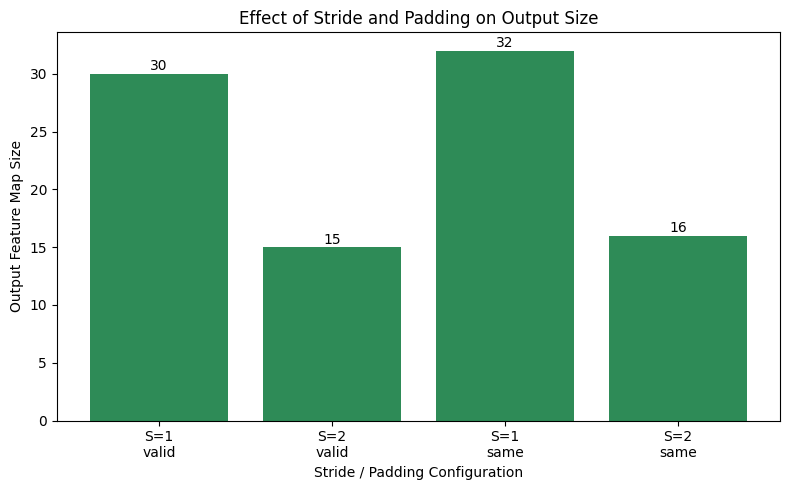

In [20]:
# Cell 10: Bar chart comparing all 4 configs
fig, ax = plt.subplots(figsize=(8, 5))
labels = [f"S={r['stride']}\n{r['padding']}" for r in results]
sizes = [r["output_size"] for r in results]
ax.bar(labels, sizes, color='seagreen')
ax.set_xlabel("Stride / Padding Configuration")
ax.set_ylabel("Output Feature Map Size")
ax.set_title("Effect of Stride and Padding on Output Size")
for i, s in enumerate(sizes):
    ax.text(i, s + 0.3, str(s), ha='center')
plt.tight_layout()
save_plot(fig, "stride_padding_comparison")
plt.show()

Task 4

In [14]:
# Cell 11: Build a simple model with one conv layer to extract feature maps from
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

# Normalize a sample image (0-1 range) for cleaner conv output
sample_img = x_train[0:1].astype('float32') / 255.0  # shape (1, 32, 32, 3)

inp = Input(shape=(32, 32, 3))
conv_out = Conv2D(filters=32, kernel_size=(3, 3), strides=1,
                   padding='same', activation='relu')(inp)
feature_extractor = Model(inputs=inp, outputs=conv_out)

feature_maps = feature_extractor.predict(sample_img)
print("Feature maps shape:", feature_maps.shape)  # (1, 32, 32, 32) -> 32 filters

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Feature maps shape: (1, 32, 32, 32)


Saved plots/feature_maps_conv1.eps


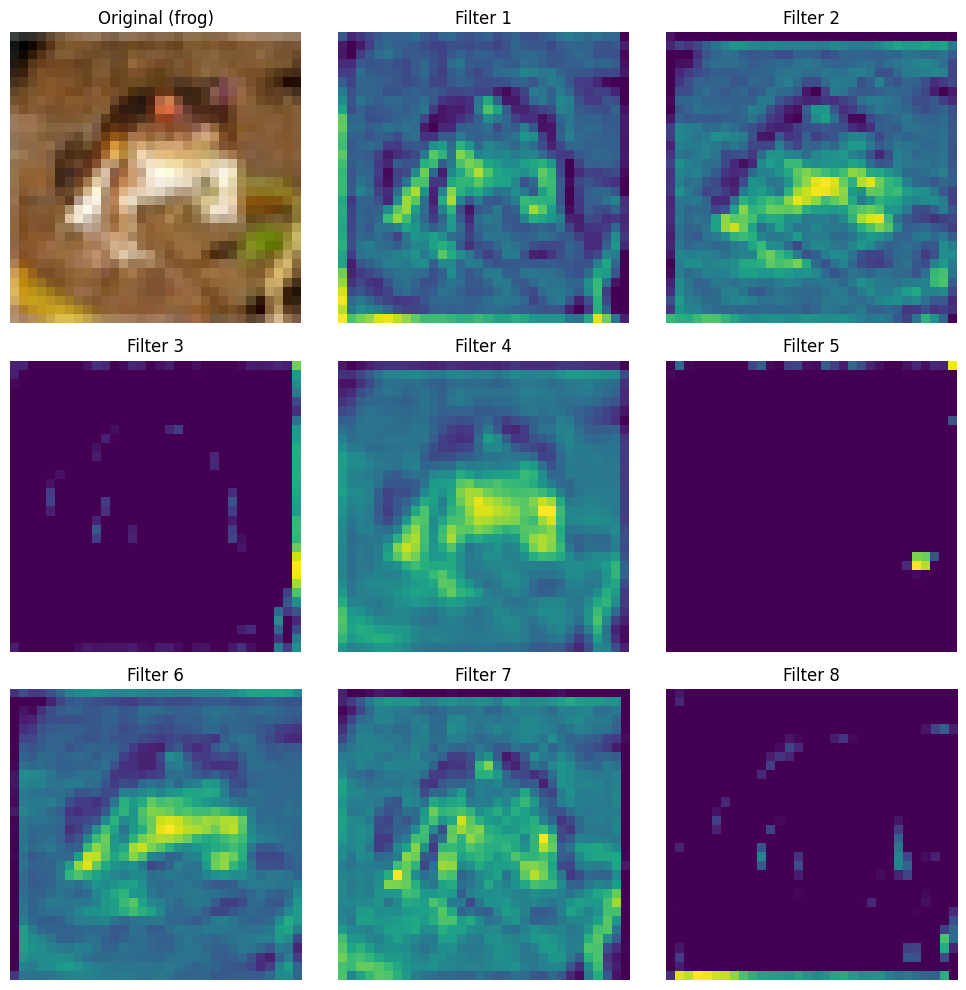

In [21]:
# Cell 12: Display the original image + at least 8 feature maps
num_maps_to_show = 8

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# First subplot: original image
axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title(f"Original ({class_names[y_train[0][0]]})")
axes[0, 0].axis('off')

# Remaining 8 subplots: feature maps from different filters
for i in range(num_maps_to_show):
    row, col = divmod(i + 1, 3)
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[row, col].set_title(f"Filter {i+1}")
    axes[row, col].axis('off')

plt.tight_layout()
save_plot(fig, "feature_maps_conv1")
plt.show()

Task 5

In [22]:
# Cell 13: Output size comparison (pooling layer alone)
from tensorflow.keras.layers import MaxPooling2D, AveragePooling2D

pool_configs = [("MaxPool", MaxPooling2D), ("AvgPool", AveragePooling2D)]
pool_size = (2, 2)
stride = 2

for name, pool_layer in pool_configs:
    model = Sequential([
        Conv2D(16, (3,3), padding='same', input_shape=(32,32,3)),
        pool_layer(pool_size=pool_size, strides=stride)
    ])
    print(f"{name} -> Output shape: {model.output_shape}")

MaxPool -> Output shape: (None, 16, 16, 16)
AvgPool -> Output shape: (None, 16, 16, 16)


In [23]:
# Cell 14: Preprocess data once (needed for training from here on)
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [24]:
# Cell 15: Build two small identical CNNs, differing only in pooling type
from tensorflow.keras.layers import Flatten, Dense

def build_small_cnn(pool_layer):
    model = Sequential([
        Conv2D(16, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        pool_layer(pool_size=(2,2)),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        pool_layer(pool_size=(2,2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_max = build_small_cnn(MaxPooling2D)
model_avg = build_small_cnn(AveragePooling2D)

In [25]:
# Cell 16: Train both briefly (5 epochs, just for comparison purposes)
print("Training with MaxPooling...")
history_max = model_max.fit(x_train_norm, y_train_cat, epochs=5, batch_size=64,
                             validation_data=(x_test_norm, y_test_cat), verbose=1)

print("\nTraining with AveragePooling...")
history_avg = model_avg.fit(x_train_norm, y_train_cat, epochs=5, batch_size=64,
                             validation_data=(x_test_norm, y_test_cat), verbose=1)

Training with MaxPooling...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.4586 - loss: 1.5106 - val_accuracy: 0.5521 - val_loss: 1.2661
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.5899 - loss: 1.1595 - val_accuracy: 0.6036 - val_loss: 1.1144
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.6413 - loss: 1.0306 - val_accuracy: 0.6240 - val_loss: 1.0959
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.6636 - loss: 0.9590 - val_accuracy: 0.6499 - val_loss: 1.0160
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6875 - loss: 0.8951 - val_accuracy: 0.6677 - val_loss: 0.9637

Training with AveragePooling...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4222 - loss: 1.6081 - val_accuracy: 0.4814 - val_loss: 1.4549
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.5350 - loss: 1.3066 - val_accuracy: 0.5635 - val_loss: 1.2394
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━

MaxPooling final val accuracy: 0.6677
AveragePooling final val accuracy: 0.6185
Saved plots/maxpool_vs_avgpool_accuracy.eps


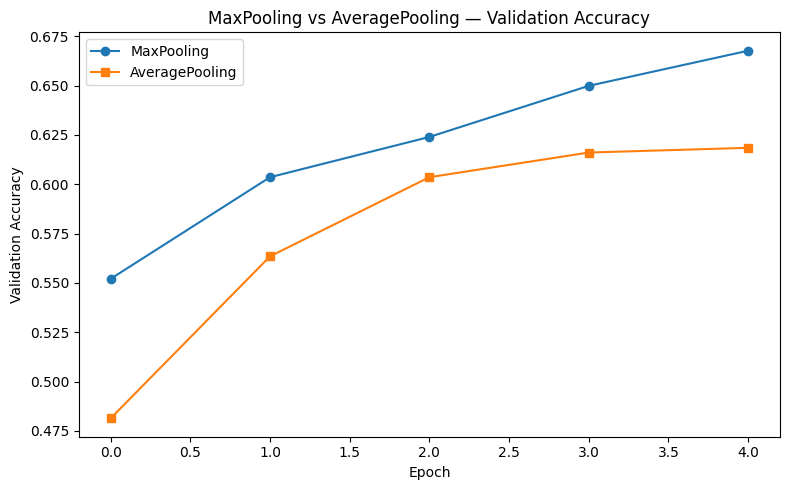

In [26]:
# Cell 17: Compare final test accuracy + plot validation accuracy curves
max_acc = history_max.history['val_accuracy'][-1]
avg_acc = history_avg.history['val_accuracy'][-1]
print(f"MaxPooling final val accuracy: {max_acc:.4f}")
print(f"AveragePooling final val accuracy: {avg_acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_max.history['val_accuracy'], label='MaxPooling', marker='o')
ax.plot(history_avg.history['val_accuracy'], label='AveragePooling', marker='s')
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("MaxPooling vs AveragePooling — Validation Accuracy")
ax.legend()
plt.tight_layout()
save_plot(fig, "maxpool_vs_avgpool_accuracy")
plt.show()

In [27]:
# Cell 18: Build the specified CNN architecture
def build_main_cnn():
    model = Sequential([
        Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        tf.keras.layers.ReLU(),
        MaxPooling2D(pool_size=(2,2)),

        Conv2D(64, (3,3), padding='same'),
        tf.keras.layers.ReLU(),
        MaxPooling2D(pool_size=(2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

main_model = build_main_cnn()
main_model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Cell 19: Compile with Adam optimizer
main_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
# Cell 20: Train — 20 epochs, batch size 32
history_main = main_model.fit(
    x_train_norm, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(x_test_norm, y_test_cat),
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.5127 - loss: 1.3691 - val_accuracy: 0.6229 - val_loss: 1.0644
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6503 - loss: 0.9939 - val_accuracy: 0.6617 - val_loss: 0.9715
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 44ms/step - accuracy: 0.7059 - loss: 0.8440 - val_accuracy: 0.6922 - val_loss: 0.8975
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.7406 - loss: 0.7401 - val_accuracy: 0.7040 - val_loss: 0.8675
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 35ms/step - accuracy: 0.7724 - loss: 0.6472 - val_accuracy: 0.7064 - val_loss: 0.8591
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.7989 - loss: 0.5704 - val_accuracy: 0.7053 - val_loss: 0.9088
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.8273 - loss: 0.4919 - val_accuracy: 0.7061 - val_loss: 0.9414
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.8490 -

In [30]:
# Cell 21: Get predictions on test set
y_pred_probs = main_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()  # y_test is (10000,1), flatten to (10000,)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step


In [31]:
# Cell 22: Accuracy, Precision, Recall, F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7003
Precision: 0.6987
Recall:    0.7003
F1-score:  0.6980


Saved plots/confusion_matrix.eps


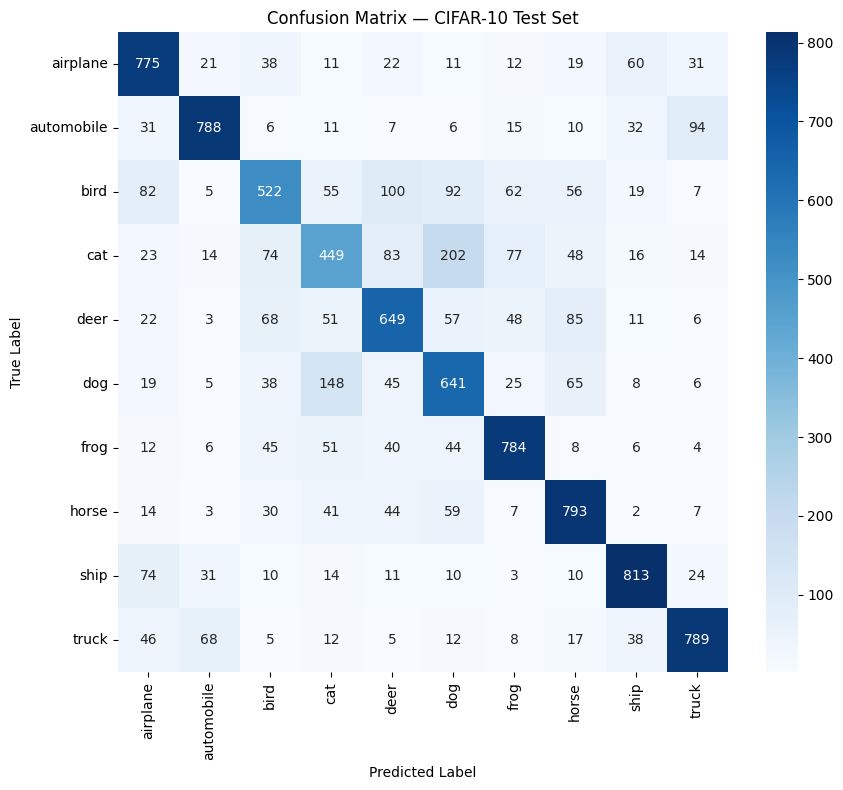

In [32]:
# Cell 23: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix — CIFAR-10 Test Set")
plt.tight_layout()
save_plot(fig, "confusion_matrix")
plt.show()

In [33]:
# Cell 24: Classification Report
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save it as a text file too, useful for your results section
with open('plots/classification_report.txt', 'w') as f:
    f.write(report)

              precision    recall  f1-score   support

    airplane       0.71      0.78      0.74      1000
  automobile       0.83      0.79      0.81      1000
        bird       0.62      0.52      0.57      1000
         cat       0.53      0.45      0.49      1000
        deer       0.65      0.65      0.65      1000
         dog       0.57      0.64      0.60      1000
        frog       0.75      0.78      0.77      1000
       horse       0.71      0.79      0.75      1000
        ship       0.81      0.81      0.81      1000
       truck       0.80      0.79      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



Saved plots/training_validation_accuracy.eps


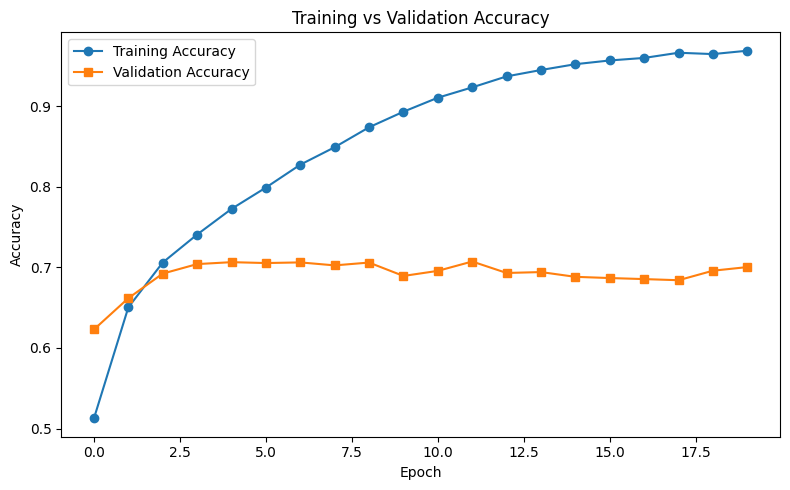

Saved plots/training_validation_loss.eps


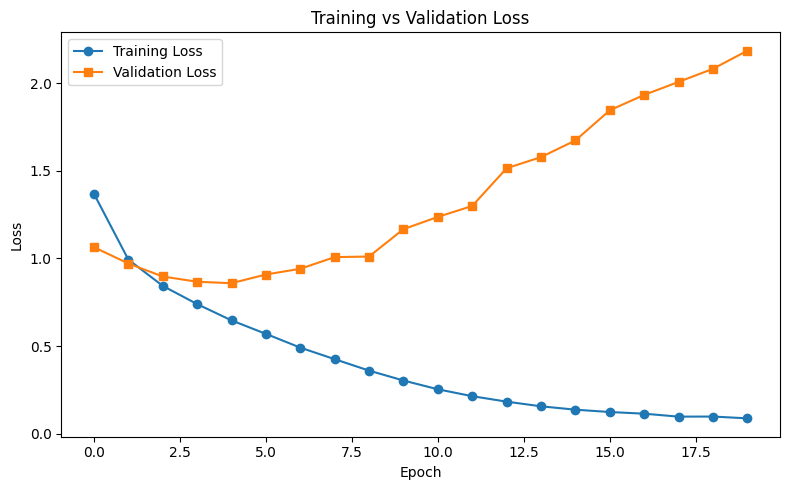

In [34]:
# Cell 25: Mandatory plots — Training/Validation Accuracy and Loss (from Task 6's history_main)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_main.history['accuracy'], label='Training Accuracy', marker='o')
ax.plot(history_main.history['val_accuracy'], label='Validation Accuracy', marker='s')
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Validation Accuracy")
ax.legend()
plt.tight_layout()
save_plot(fig, "training_validation_accuracy")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_main.history['loss'], label='Training Loss', marker='o')
ax.plot(history_main.history['val_loss'], label='Validation Loss', marker='s')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
plt.tight_layout()
save_plot(fig, "training_validation_loss")
plt.show()